# Tech Challenge - Fase 3: Modelagem Supervisionada (Classificacao de Risco Educacional)

**Objetivo:** prever quais municipios apresentam **risco educacional** (`classe_taxa == 'muito_baixo'`), a partir de variaveis territoriais, socioeconomicas e educacionais, sem uso de dados que configurem *data leakage*.

**Estrategia de validacao:**
- Split temporal: treino em **2023**, teste em **2024** (avaliacao de generalizacao real no horizonte futuro);
- `GroupKFold` por UF dentro do treino, para tuning sem vazamento espacial.

**Modelos comparados:** Regressao Logistica (baseline interpretavel), Random Forest e XGBoost.

> Este notebook e autocontido: todas as funcoes de preparacao, modelagem e explicabilidade
> estao definidas diretamente nas celulas abaixo (nao dependem de importar o pacote `src/`
> nem de manipular o diretorio de trabalho). O modulo `src/` do repositorio contem a mesma
> logica organizada em arquivos `.py`, caso voce prefira reutiliza-la em outro script.


## 0. Imports

Cada biblioteca é importada individualmente (sem `sys.path` nem dependência da raiz do projeto).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, confusion_matrix, classification_report,
)

from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', 50)


ImportError: C extension: None not built. If you want to import pandas from the source directory, you may need to run 'python setup.py build_ext' to build the C extensions first.

### Onde está o `Data.csv`?

Em vez de descobrir a raiz do projeto e mudar o diretório de trabalho, o notebook
apenas testa os dois caminhos relativos mais comuns (rodando a partir da pasta
`notebooks/`, ou a partir da raiz do repositório) e usa o que existir. Se nenhum
existir, ajuste `CAMINHO_DADOS` manualmente na célula abaixo.

In [2]:
candidatos = [
    Path('data/raw/Data.csv'),       # caso o notebook rode com cwd = raiz do repositorio (comum no VSCode)
    Path('../data/raw/Data.csv'),    # caso o notebook rode com cwd = pasta notebooks/ (Jupyter classico)
]

CAMINHO_DADOS = next((c for c in candidatos if c.exists()), None)

if CAMINHO_DADOS is None:
    # Ajuste manual: cole aqui o caminho absoluto do seu Data.csv
    CAMINHO_DADOS = Path('data/raw/Data.csv')
    print(f"AVISO: nao encontrei o arquivo nos caminhos padrao. Ajuste CAMINHO_DADOS manualmente.")

print(f"Usando dados em: {CAMINHO_DADOS.resolve()}")


Usando dados em: /home/claude/tech-challenge-fase3/data/raw/Data.csv


## 1. Preparacao dos dados

Aplica, na ordem correta:
1. Imputacao estrutural de PIB (forward-fill ajustado por populacao);
2. Remocao de `computadores_por_aluno` (100% nulo);
3. Construcao do target de risco;
4. Remocao de linhas sem `taxa_alfabetizacao`;
5. Remocao de colunas de *data leakage*.


In [3]:
# Colunas que NAO podem ser usadas como preditoras (vazamento de dados).
# Sao derivadas da propria taxa de alfabetizacao atual ou de metas futuras.
LEAKAGE_COLUMNS = [
    "gap_meta_2030",
    "nivel_alfabetizacao",
    "classe_taxa",
    "meta_alfabetizacao_2024",
    "meta_alfabetizacao_2025",
    "meta_alfabetizacao_2026",
    "meta_alfabetizacao_2027",
    "meta_alfabetizacao_2028",
    "meta_alfabetizacao_2029",
    "meta_alfabetizacao_2030",
    "status_meta_2030",  # usada so para construir o target, nunca como feature
]
# NOTA: `meta_alfabetizacao_2024` foi incluida aqui apos verificarmos empiricamente que
# ela e fortemente correlacionada com o proprio target: municipios 'muito_baixo' tem meta
# media de ~40 pontos, contra ~76 nos 'adequado_total'. Ou seja, a meta de curto prazo ja
# foi calibrada pela propria Secretaria com base no patamar atual de alfabetizacao do
# municipio - um proxy quase tautologico do target. Mante-la produzia ROC-AUC ~1.00 em
# validacao cruzada, sinal claro de vazamento/trivializacao do problema.

COL_100_NULA = "computadores_por_aluno"
TARGET_CLASSIFICACAO = "risco_educacional"
TARGET_REGRESSAO = "taxa_alfabetizacao"


In [4]:
def construir_target_risco(df):
    """
    risco_educacional = 1 se classe_taxa == 'muito_baixo', senao 0.
    Municipios com classe_taxa == 'sem_dado' sao removidos (nao ha como rotular).
    """
    df = df[df["classe_taxa"] != "sem_dado"].copy()
    df[TARGET_CLASSIFICACAO] = (df["classe_taxa"] == "muito_baixo").astype(int)
    return df


def imputar_pib_forward_fill(df):
    """
    Imputa pib/pib_per_capita de 2024 (100% nulo nesse ano) usando o historico
    municipal de 2023, ajustado pela variacao populacional entre os dois anos:
        pib_2024_imputado = pib_2023 * (populacao_2024 / populacao_2023)
    """
    df = df.sort_values(["id_municipio", "ano"]).copy()

    pib_2023 = (
        df[df["ano"] == 2023][["id_municipio", "pib", "populacao"]]
        .rename(columns={"pib": "pib_2023", "populacao": "populacao_2023"})
    )
    df = df.merge(pib_2023, on="id_municipio", how="left")

    mask_2024_nulo = (df["ano"] == 2024) & (df["pib"].isna())
    fator_pop = df["populacao"] / df["populacao_2023"]
    pib_imputado = df["pib_2023"] * fator_pop

    df.loc[mask_2024_nulo, "pib"] = pib_imputado[mask_2024_nulo]
    df.loc[mask_2024_nulo, "pib_per_capita"] = (
        df.loc[mask_2024_nulo, "pib"] / df.loc[mask_2024_nulo, "populacao"]
    )
    return df.drop(columns=["pib_2023", "populacao_2023"])


def preparar_base(caminho):
    df = pd.read_csv(caminho)
    df = imputar_pib_forward_fill(df)
    if COL_100_NULA in df.columns:
        df = df.drop(columns=[COL_100_NULA])
    df = construir_target_risco(df)
    df = df.dropna(subset=[TARGET_REGRESSAO])
    cols_drop = [c for c in LEAKAGE_COLUMNS if c in df.columns]
    df = df.drop(columns=cols_drop)
    return df


def listar_features(df):
    excluir = {TARGET_CLASSIFICACAO, TARGET_REGRESSAO, "id_municipio", "nome_municipio", "ano"}
    categoricas = [c for c in ["sigla_uf", "nome_regiao"] if c in df.columns and c not in excluir]
    numericas = [
        c for c in df.select_dtypes(include=["int64", "float64"]).columns
        if c not in excluir and c not in categoricas
    ]
    return numericas, categoricas


In [5]:
df = preparar_base(CAMINHO_DADOS)
print(f"Shape final: {df.shape}")
print("Distribuicao do target (risco_educacional):")
print(df[TARGET_CLASSIFICACAO].value_counts(normalize=True).round(3))
df.head(3)


Shape final: (10584, 25)
Distribuicao do target (risco_educacional):
risco_educacional
0    0.849
1    0.151
Name: proportion, dtype: float64


,ano,id_municipio,taxa_alfabetizacao,percentual_participacao,nome_municipio,sigla_uf,nome_uf,nome_regiao,capital_uf,amazonia_legal,populacao,pib,pib_per_capita,qtd_escolas,matriculas_anos_iniciais,docentes_anos_iniciais,razao_aluno_docente,pct_escolas_internet,pct_escolas_biblioteca,pct_escolas_lab_informatica,pct_escolas_agua_potavel,pct_escolas_energia_publica,pct_escolas_esgoto_publico,pct_escolas_quadra_esportes,risco_educacional
0,2023,1100015,64.60,89.37,Alta Floresta D'Oeste,RO,Rondônia,Norte,0,1,21494,1.046343e+09,48680.701591,18,1368,62,22.064516,1.000000,0.285714,0.000000,1.000000,1.0,0.0,0.714286,0
1,2024,1100015,67.79,89.87,Alta Floresta D'Oeste,RO,Rondônia,Norte,0,1,22853,1.112500e+09,48680.701591,19,1442,55,26.218182,0.933333,0.266667,0.000000,1.000000,1.0,0.0,0.600000,0
2,2023,1100023,62.30,89.79,Ariquemes,RO,Rondônia,Norte,0,1,96833,4.383815e+09,45271.911435,30,5704,249,22.907631,1.000000,0.592593,0.851852,0.962963,1.0,0.0,0.555556,0


### Colunas removidas do espaco de features (data leakage)
`gap_meta_2030`, `nivel_alfabetizacao`, `classe_taxa`, `meta_alfabetizacao_2024..2030`, `status_meta_2030`.

In [6]:
features_numericas, features_categoricas = listar_features(df)
print(f"Features numericas ({len(features_numericas)}): {features_numericas}")
print(f"Features categoricas ({len(features_categoricas)}): {features_categoricas}")


Features numericas (17): ['percentual_participacao', 'capital_uf', 'amazonia_legal', 'populacao', 'pib', 'pib_per_capita', 'qtd_escolas', 'matriculas_anos_iniciais', 'docentes_anos_iniciais', 'razao_aluno_docente', 'pct_escolas_internet', 'pct_escolas_biblioteca', 'pct_escolas_lab_informatica', 'pct_escolas_agua_potavel', 'pct_escolas_energia_publica', 'pct_escolas_esgoto_publico', 'pct_escolas_quadra_esportes']
Features categoricas (2): ['sigla_uf', 'nome_regiao']


## 2. Split temporal (2023 -> treino, 2024 -> teste)

In [7]:
df_treino = df[df["ano"] == 2023].copy()
df_teste = df[df["ano"] == 2024].copy()
print(f"Treino (2023): {df_treino.shape[0]} municipios")
print(f"Teste  (2024): {df_teste.shape[0]} municipios")

X_treino = df_treino[features_numericas + features_categoricas]
y_treino = df_treino[TARGET_CLASSIFICACAO]
X_teste = df_teste[features_numericas + features_categoricas]
y_teste = df_teste[TARGET_CLASSIFICACAO]


Treino (2023): 5232 municipios
Teste  (2024): 5352 municipios


## 3. Pipeline de pre-processamento + modelo

Numericas: imputacao por mediana + padronizacao.
Categoricas: imputacao por moda + one-hot encoding.


In [8]:
def construir_pipeline(features_numericas, features_categoricas, modelo="random_forest", random_state=42):
    transf_numerico = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    transf_categorico = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessador = ColumnTransformer(transformers=[
        ("num", transf_numerico, features_numericas),
        ("cat", transf_categorico, features_categoricas),
    ])

    if modelo == "logistic_regression":
        clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state)
    elif modelo == "random_forest":
        clf = RandomForestClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=5,
            class_weight="balanced", random_state=random_state, n_jobs=-1,
        )
    elif modelo == "xgboost":
        clf = XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", random_state=random_state, n_jobs=-1,
        )
    else:
        raise ValueError(f"Modelo '{modelo}' nao suportado.")

    return Pipeline(steps=[("preprocessador", preprocessador), ("classificador", clf)])


## 4. Validacao cruzada dentro do treino: `GroupKFold` por UF

Garante que municipios da mesma UF nao fiquem simultaneamente em treino e validacao (evita vazamento espacial).

In [9]:
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(X_treino, groups=df_treino["sigla_uf"]))

resultados_cv = {}
for nome_modelo in ["logistic_regression", "random_forest", "xgboost"]:
    pipeline = construir_pipeline(features_numericas, features_categoricas, modelo=nome_modelo)
    scores = cross_validate(
        pipeline, X_treino, y_treino,
        cv=folds, scoring=["roc_auc", "f1", "average_precision"], n_jobs=-1,
    )
    resultados_cv[nome_modelo] = {
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "pr_auc_mean": scores["test_average_precision"].mean(),
    }

pd.DataFrame(resultados_cv).T.round(4)


,roc_auc_mean,roc_auc_std,f1_mean,pr_auc_mean
logistic_regression,0.8091,0.0380,0.4525,0.4273
random_forest,0.7925,0.0532,0.4482,0.4121
xgboost,0.7915,0.0584,0.2042,0.4061


## 5. Treino final e avaliacao no conjunto de teste real (2024)

O modelo com melhor ROC-AUC medio em validacao cruzada e retreinado com todo o treino de 2023 e avaliado no ano de 2024 (dado nunca visto).

In [10]:
melhor_modelo = max(resultados_cv, key=lambda k: resultados_cv[k]["roc_auc_mean"])
print(f"Melhor modelo por ROC-AUC medio (CV): {melhor_modelo}")

pipeline_final = construir_pipeline(features_numericas, features_categoricas, modelo=melhor_modelo)
pipeline_final.fit(X_treino, y_treino)

y_proba_teste = pipeline_final.predict_proba(X_teste)[:, 1]
y_pred_teste = pipeline_final.predict(X_teste)

metricas = {
    "roc_auc": roc_auc_score(y_teste, y_proba_teste),
    "pr_auc": average_precision_score(y_teste, y_proba_teste),
    "f1": f1_score(y_teste, y_pred_teste),
    "precision": precision_score(y_teste, y_pred_teste),
    "recall": recall_score(y_teste, y_pred_teste),
}
print("=== Metricas (holdout 2024) ===")
for k, v in metricas.items():
    print(f"{k}: {v:.4f}")

print("\n=== Matriz de Confusao ===")
print(confusion_matrix(y_teste, y_pred_teste))

print("\n=== Classification Report ===")
print(classification_report(y_teste, y_pred_teste, target_names=["baixo_risco", "alto_risco"]))


Melhor modelo por ROC-AUC medio (CV): logistic_regression
=== Metricas (holdout 2024) ===
roc_auc: 0.8193
pr_auc: 0.4901
f1: 0.5120
precision: 0.3820
recall: 0.7763

=== Matriz de Confusao ===
[[3678  932]
 [ 166  576]]

=== Classification Report ===
              precision    recall  f1-score   support

 baixo_risco       0.96      0.80      0.87      4610
  alto_risco       0.38      0.78      0.51       742

    accuracy                           0.79      5352
   macro avg       0.67      0.79      0.69      5352
weighted avg       0.88      0.79      0.82      5352



## 6. Explicabilidade: Feature Importance e SHAP

Usados para auditar as decisoes do modelo e apoiar gestores publicos na priorizacao de politicas educacionais.

In [11]:
def obter_nomes_features(pipeline):
    return list(pipeline.named_steps["preprocessador"].get_feature_names_out())


modelo_final = pipeline_final.named_steps["classificador"]
nomes_feat = obter_nomes_features(pipeline_final)

if hasattr(modelo_final, "feature_importances_"):
    importancias = modelo_final.feature_importances_
elif hasattr(modelo_final, "coef_"):
    importancias = np.abs(modelo_final.coef_).ravel()
else:
    raise ValueError("Modelo nao expoe feature_importances_ nem coef_.")

df_importancia = pd.DataFrame({"feature": nomes_feat, "importancia": importancias})
df_importancia = df_importancia.sort_values("importancia", ascending=False).reset_index(drop=True)
df_importancia.head(15)


,feature,importancia
0,cat__sigla_uf_CE,3.141501
1,cat__sigla_uf_SE,2.640217
2,cat__sigla_uf_MS,1.973618
3,cat__sigla_uf_PE,1.834825
4,cat__sigla_uf_TO,1.655288
5,cat__nome_regiao_Sul,1.620546
6,cat__sigla_uf_ES,1.611610
7,cat__sigla_uf_BA,1.555101
8,cat__sigla_uf_AL,1.533499
9,cat__sigla_uf_MA,1.533299


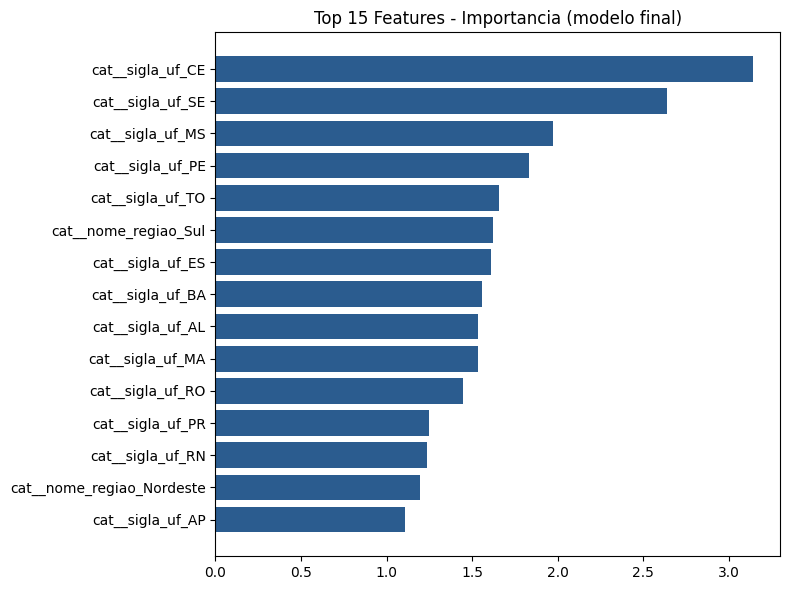

In [12]:
plt.figure(figsize=(8, 6))
top15 = df_importancia.head(15).sort_values("importancia")
plt.barh(top15["feature"], top15["importancia"], color="#2b5c8f")
plt.title("Top 15 Features - Importancia (modelo final)")
plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig("images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


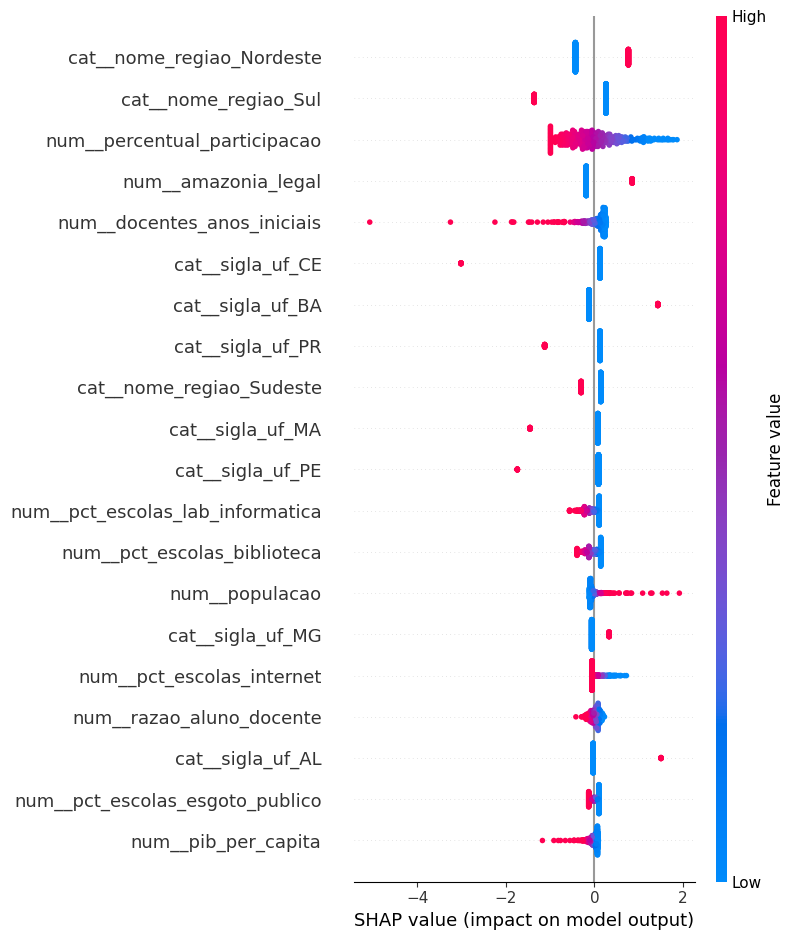

In [13]:
amostra_shap = X_treino.sample(min(500, len(X_treino)), random_state=42)
preprocessador = pipeline_final.named_steps["preprocessador"]
X_transformado = preprocessador.transform(amostra_shap)
if hasattr(X_transformado, "toarray"):
    X_transformado = X_transformado.toarray()

if type(modelo_final).__name__ == "LogisticRegression":
    explainer = shap.LinearExplainer(modelo_final, X_transformado)
else:
    explainer = shap.TreeExplainer(modelo_final)

shap_values = explainer.shap_values(X_transformado)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure()
shap.summary_plot(shap_values, X_transformado, feature_names=nomes_feat, show=False)
plt.savefig("images/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# Direcao do efeito: coeficientes com sinal (quando o modelo final e a Regressao Logistica)
# Positivo = aumenta a chance de risco educacional | Negativo = reduz a chance
if hasattr(modelo_final, "coef_"):
    coefs = pd.DataFrame({"feature": nomes_feat, "coef": modelo_final.coef_.ravel()}).sort_values("coef")
    print("=== Fatores associados a MAIOR risco (coef positivo) ===")
    display(coefs.tail(10))
    print("\n=== Fatores associados a MENOR risco / protecao (coef negativo) ===")
    display(coefs.head(10))


=== Fatores associados a MAIOR risco (coef positivo) ===


,feature,coef
33,cat__sigla_uf_RJ,0.476693
3,num__populacao,0.763011
19,cat__sigla_uf_AP,1.107171
42,cat__nome_regiao_Nordeste,1.196090
34,cat__sigla_uf_RN,1.236552
17,cat__sigla_uf_AL,1.533499
20,cat__sigla_uf_BA,1.555101
40,cat__sigla_uf_TO,1.655288
26,cat__sigla_uf_MS,1.973618
38,cat__sigla_uf_SE,2.640217



=== Fatores associados a MENOR risco / protecao (coef negativo) ===


,feature,coef
21,cat__sigla_uf_CE,-3.141501
30,cat__sigla_uf_PE,-1.834825
45,cat__nome_regiao_Sul,-1.620546
22,cat__sigla_uf_ES,-1.611610
24,cat__sigla_uf_MA,-1.533299
35,cat__sigla_uf_RO,-1.446065
32,cat__sigla_uf_PR,-1.250091
23,cat__sigla_uf_GO,-1.063529
8,num__docentes_anos_iniciais,-0.918883
18,cat__sigla_uf_AM,-0.856458


### Leitura de negocio dos resultados

**O que mais explica o risco educacional, segundo o modelo:**

- **Efeito de UF/regiao domina sobre as variaveis estruturais.** Ja era esperado: alfabetizacao no Brasil tem forte componente historico/institucional por estado.
- **Ceara e o destaque mais relevante do modelo** (mais protetor de todos): mesmo estando na regiao Nordeste - que tem a segunda maior taxa media de risco entre as regioes (30,3%, atras apenas do Norte, 33,2%) -, o estado do Ceara puxa a previsao fortemente para *baixo risco*. Isso e consistente com o **PAIC (Programa Alfabetizacao na Idade Certa)**, referencia nacional em alfabetizacao desde os anos 2000. O modelo "descobriu" esse efeito sozinho, a partir apenas dos dados.
- **`docentes_anos_iniciais` e protetor**: mais professores esta associado a menor risco - alavanca de politica publica acionavel de curto prazo.
- **`percentual_participacao` e protetor**: municipios com maior adesao/participacao na avaliacao tem, em media, menor risco.
- **`amazonia_legal` e `populacao` aumentam o risco previsto**, reforcando o padrao regional de desigualdade ja visto na EDA.

**Limitacao importante:** `sigla_uf` e `nome_regiao` sao colineares (cada UF pertence a uma unica regiao), entao os coeficientes individuais devem ser lidos com cautela - capturam efeito conjunto UF+regiao. O SHAP mitiga isso ao calcular contribuicao por instancia.

**Aplicacao pratica para gestores publicos:**
1. Priorizar visitas tecnicas e apoio pedagogico aos municipios do **Norte e Nordeste** (exceto padroes ja bem-sucedidos como CE), com foco redobrado na **Amazonia Legal**.
2. Investigar o **dimensionamento docente** como alavanca de curto prazo.
3. Estudar o **modelo de gestao do Ceara** como referencia replicavel para estados com perfil similar mas desempenho pior.
4. Usar o **score de probabilidade do modelo** (nao so a classificacao binaria) para priorizar municipios.


## 7. Proximos passos sugeridos
- Tuning de hiperparametros (ex.: `RandomizedSearchCV` respeitando o `GroupKFold`);
- Ajustar o threshold de decisao via curva precision-recall;
- Repetir a mesma pipeline para o cenario de regressao (`taxa_alfabetizacao` continua) como analise complementar;
- Registrar decisoes e resultados no README e no video executivo.
